In [8]:
import os
import random
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.decomposition import PCA
from collections import defaultdict
from scipy.stats import wasserstein_distance

###############################################################################
# KLL Sketch Implementation
###############################################################################
class KLLSketch1D:
    """
    A very lightweight KLL sketch for one-dimensional numeric data.
    This example doesn't handle merges and compressions exhaustively,
    but illustrates the core approach for demonstration purposes.
    """

    def __init__(self, capacity=200):
        """
        capacity: maximum size of the reservoir before compression
        """
        self.capacity = capacity
        self.levels = [[]]  # Each 'level' is a reservoir of samples
        self.total_count = 0

    def update(self, value):
        """
        Insert a new value into the sketch, compressing if needed.
        """
        self.levels[0].append(value)
        self.total_count += 1
        if len(self.levels[0]) > self.capacity:
            self._compress_level(0)

    def _compress_level(self, lvl):
        """
        Compress the reservoir at level 'lvl' into level 'lvl+1'.
        Half of the items from level 'lvl' get randomly discarded,
        the rest move up to level 'lvl+1'.
        """
        if lvl + 1 >= len(self.levels):
            self.levels.append([])
        reservoir = self.levels[lvl]
        # Sort the reservoir so that picking "every other" item is simpler
        reservoir.sort()
        # Every other item is "kept" (or dropped). We'll keep the even indices for example.
        compressed = reservoir[::2]  # keep items at even indices
        self.levels[lvl+1].extend(compressed)
        self.levels[lvl].clear()

        # If next level is beyond capacity, compress further
        if len(self.levels[lvl+1]) > self.capacity:
            self._compress_level(lvl+1)

    def get_quantile(self, q):
        """
        Approximate the quantile 'q' (0 <= q <= 1).
        We flatten all levels, because this minimal example
        doesn't do weighted levels. In a real KLL, levels are weighted.
        """
        all_data = []
        for lvl in self.levels:
            all_data.extend(lvl)
        # Sort, pick the rank
        all_data.sort()
        rank = int(q * (len(all_data) - 1))
        return all_data[rank] if all_data else None

    def get_cdf(self, values):
        """
        Approximate the CDF for each value in 'values'.
        Returns a list of cdf(value) for each input value.
        """
        # Flatten everything
        all_data = []
        for lvl in self.levels:
            all_data.extend(lvl)
        if not all_data:
            return [0.0] * len(values)

        all_data.sort()
        cdfs = []
        n = len(all_data)
        idx = 0
        for v in values:
            # Move 'idx' until all_data[idx] <= v
            while idx < n and all_data[idx] <= v:
                idx += 1
            cdfs.append(idx / n)
        return cdfs

def kll_kolmogorov_smirnov_distance(sketchA, sketchB, num_grid=100):
    """
    Example: Compare two 1D KLL sketches using an approximate KS statistic.
    1) We pick 'num_grid' equally spaced quantiles or a set of test values.
    2) We compute the difference in CDFs and take the maximum.
    """
    if sketchA.total_count == 0 or sketchB.total_count == 0:
        return 0.0

    # We'll get min/max from each sketch
    minA = sketchA.get_quantile(0.0)
    maxA = sketchA.get_quantile(1.0)
    minB = sketchB.get_quantile(0.0)
    maxB = sketchB.get_quantile(1.0)

    global_min = min(minA, minB)
    global_max = max(maxA, maxB)
    if global_min == global_max:
        return 0.0

    # Build a set of test values in [global_min, global_max]
    test_vals = np.linspace(global_min, global_max, num_grid)

    cdfA = sketchA.get_cdf(test_vals)
    cdfB = sketchB.get_cdf(test_vals)

    # KS distance = max|CDF_A(x) - CDF_B(x)|
    return max(abs(a - b) for (a, b) in zip(cdfA, cdfB))

###############################################################################
# Arguments
###############################################################################
args = {
    "models": [
        "nlpaueb/sec-bert-base",
        "bert-base-uncased"
    ],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "ag_news",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
    ],
    "max_texts": 100,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "output_dir": "data-analysis/data",
    "hist_bins": 30,
    "num_seeds": 3,
    "kl_eps": 1e-12,
    "use_adaptive_gamma": True,
    # Sketch-related:
    "kll_capacity": 200,
    "kll_num_grid": 100
}
os.makedirs(args["output_dir"], exist_ok=True)

###############################################################################
# Utility Functions
###############################################################################
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()

def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    """
    Simple 'drift' function that shuffles a fraction of words in each text.
    """
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts

###############################################################################
# 1) Building Distribution Histograms in 2D
###############################################################################
def build_2d_hist(embs_2d, bins=30):
    hist, xedges, yedges = np.histogram2d(
        embs_2d[:, 0],
        embs_2d[:, 1],
        bins=bins,
        density=False
    )
    hist = hist / hist.sum()
    return hist, xedges, yedges

###############################################################################
# 2) Common Distribution-Based Distances or Divergences
###############################################################################
def safe_prob(p, eps=1e-12):
    return np.maximum(p, eps)

def kl_divergence(p, q, kl_eps=1e-12):
    p_ = safe_prob(p, eps=kl_eps)
    q_ = safe_prob(q, eps=kl_eps)
    return np.sum(p_ * np.log(p_ / q_))

def js_divergence(p, q, kl_eps=1e-12):
    p_ = safe_prob(p, eps=kl_eps)
    q_ = safe_prob(q, eps=kl_eps)
    m_ = 0.5 * (p_ + q_)
    return 0.5 * kl_divergence(p_, m_, kl_eps=kl_eps) + 0.5 * kl_divergence(q_, m_, kl_eps=kl_eps)

def hellinger_distance(p, q, kl_eps=1e-12):
    p_ = np.sqrt(safe_prob(p, eps=kl_eps))
    q_ = np.sqrt(safe_prob(q, eps=kl_eps))
    return np.sqrt(np.sum((p_ - q_)**2) / 2.0)

def bhattacharyya_distance(p, q, kl_eps=1e-12):
    bc = np.sum(np.sqrt(safe_prob(p, eps=kl_eps) * safe_prob(q, eps=kl_eps)))
    return -np.log(bc + 1e-12)

def compute_2d_hist_distance(baseline_embs, new_embs, measure="js",
                             bins=30, kl_eps=1e-12):
    hist_p, xedges, yedges = build_2d_hist(baseline_embs, bins=bins)
    hist_q_raw, _, _ = np.histogram2d(
        new_embs[:, 0],
        new_embs[:, 1],
        bins=[xedges, yedges],
        density=False
    )
    hist_q = hist_q_raw / hist_q_raw.sum()
    p = hist_p.flatten()
    q = hist_q.flatten()

    if measure == "kl":
        return kl_divergence(p, q, kl_eps=kl_eps)
    elif measure == "js":
        return js_divergence(p, q, kl_eps=kl_eps)
    elif measure == "hellinger":
        return hellinger_distance(p, q, kl_eps=kl_eps)
    elif measure == "bhattacharyya":
        return bhattacharyya_distance(p, q, kl_eps=kl_eps)
    else:
        raise ValueError(f"Unknown measure: {measure}")

###############################################################################
# 3) MMD Computation
###############################################################################
def rbf_kernel(x, y, gamma=1.0):
    x2 = np.sum(x**2, axis=1)[:, None]
    y2 = np.sum(y**2, axis=1)[None, :]
    dist2 = x2 + y2 - 2*np.dot(x, y.T)
    return np.exp(-gamma * dist2)

def compute_mmd(baseline_embs, new_embs, gamma=0.5):
    X = baseline_embs
    Y = new_embs
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    m = len(X)
    n = len(Y)

    mmd2 = XX.sum() / (m**2) + YY.sum() / (n**2) - 2.0 * XY.sum() / (m*n)
    return np.sqrt(mmd2)

def auto_select_gamma(embs):
    sample = embs
    if len(embs) > 500:
        sample = embs[np.random.choice(len(embs), 500, replace=False)]
    dists = []
    for i in range(len(sample)-1):
        dist2 = np.sum((sample[i] - sample[i+1:])**2, axis=1)
        dists.append(dist2)
    dists = np.concatenate(dists)
    median_dist2 = np.median(dists)
    if median_dist2 <= 0.0:
        median_dist2 = 1e-6
    return 1.0 / (2.0 * median_dist2)

###############################################################################
# 4) Multi-D Wasserstein
###############################################################################
def compute_wasserstein_1D_per_dim(baseline_embs, new_embs):
    d = baseline_embs.shape[1]
    w_sum = 0.0
    for i in range(d):
        w_sum += wasserstein_distance(baseline_embs[:, i], new_embs[:, i])
    return w_sum

###############################################################################
# 5) Main function for a single seed
###############################################################################
def run_experiment_single_seed(seed, args):
    # Set the random seed
    set_seed(seed)

    # Detect device
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    print(f"[Seed={seed}] Using device:", device)
    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name  = dataset_info["name"]
        dataset_config = dataset_info["config"]
        dataset_split = dataset_info["split"]
        text_col      = dataset_info["text_column"]

        print(f"[Seed={seed}] === Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        # We'll split the data in half: baseline vs. drift region
        half_point = len(texts) // 2
        baseline_texts = texts[:half_point]
        drift_texts    = texts[half_point:]

        for model_name in args["models"]:
            print(f"[Seed={seed}] --- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name)
            model.to(device)
            model.eval()

            # Precompute baseline embeddings
            baseline_embs = []
            for b in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                baseline_embs.append(emb_b)
            baseline_embs = np.concatenate(baseline_embs, axis=0)

            # Fit PCA on the baseline embeddings
            pca = PCA(n_components=args["pca_components"])
            pca.fit(baseline_embs)
            baseline_embs_2d = pca.transform(baseline_embs)

            # Build a baseline KLL sketch for each dimension
            # (If you want to do KLL on the 2D PCA or the full dimension space, adapt accordingly.)
            baseline_sketches = []
            for dim in range(baseline_embs.shape[1]):
                sk = KLLSketch1D(capacity=args["kll_capacity"])
                for val in baseline_embs[:, dim]:
                    sk.update(val)
                baseline_sketches.append(sk)

            # If we are doing an adaptive gamma for MMD, compute it now
            if args["use_adaptive_gamma"]:
                gamma_val = auto_select_gamma(baseline_embs)
            else:
                gamma_val = 0.5

            distribution_measures = ["kl","js","hellinger",
                                     "bhattacharyya","mmd","wasserstein",
                                     "kll_ks"]  # <--- added "kll_ks"

            for measure_name in distribution_measures:
                for drift_strength in args["drift_strengths"]:
                    start_time = time.time()

                    # Create drifted text
                    drifted_texts = introduce_gradual_drift(drift_texts,
                                                            fraction_shuffle=drift_strength)
                    new_embs = []
                    for b in batch_generator(drifted_texts, args["batch_size"]):
                        emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                        new_embs.append(emb_b)
                    new_embs = np.concatenate(new_embs, axis=0)
                    new_embs_2d = pca.transform(new_embs)

                    overhead_start = time.time()
                    # Compute measure
                    if measure_name in ["kl", "js", "hellinger", "bhattacharyya"]:
                        dist_val = compute_2d_hist_distance(
                            baseline_embs_2d,
                            new_embs_2d,
                            measure=measure_name,
                            bins=args["hist_bins"],
                            kl_eps=args["kl_eps"]
                        )
                    elif measure_name == "mmd":
                        dist_val = compute_mmd(
                            baseline_embs,
                            new_embs,
                            gamma=gamma_val
                        )
                    elif measure_name == "wasserstein":
                        dist_val = compute_wasserstein_1D_per_dim(
                            baseline_embs_2d,
                            new_embs_2d
                        )
                    elif measure_name == "kll_ks":
                        # Build a new KLL sketch for each dimension, then measure KS distance
                        new_sketches = []
                        for dim in range(new_embs.shape[1]):
                            sk_new = KLLSketch1D(capacity=args["kll_capacity"])
                            for val in new_embs[:, dim]:
                                sk_new.update(val)
                            new_sketches.append(sk_new)

                        # Average (or max) the KS distance across all dimensions
                        ks_vals = []
                        for dim in range(len(baseline_sketches)):
                            ks_val = kll_kolmogorov_smirnov_distance(
                                baseline_sketches[dim],
                                new_sketches[dim],
                                num_grid=args["kll_num_grid"]
                            )
                            ks_vals.append(ks_val)
                        # For demonstration, we take the mean of the dimension-wise KS distances
                        dist_val = float(np.mean(ks_vals))
                    else:
                        dist_val = None

                    overhead_end = time.time()
                    measure_overhead = overhead_end - overhead_start

                    end_time = time.time()
                    time_taken = end_time - start_time

                    key = (dataset_name, model_name, measure_name, drift_strength)
                    results[key].append({
                        "dist_val": dist_val,
                        "time_taken": time_taken,
                        "measure_overhead": measure_overhead,
                        "seed": seed
                    })

    return results

###############################################################################
# 6) Collect data across multiple seeds
###############################################################################
def collect_data_multiple_seeds(args):
    all_results = defaultdict(list)
    for seed in range(args["num_seeds"]):
        seed_results = run_experiment_single_seed(seed, args)
        for k, list_of_records in seed_results.items():
            all_results[k].extend(list_of_records)
    print("Data collection (all seeds) done!")
    return all_results

# Run everything
all_results = collect_data_multiple_seeds(args)

[Seed=0] Using device: mps
[Seed=0] === Loading dataset: yelp_review_full ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=0] === Loading dataset: wikitext ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=0] === Loading dataset: ag_news ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=1] Using device: mps
[Seed=1] === Loading dataset: yelp_review_full ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=1] === Loading dataset: wikitext ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=1] === Loading dataset: ag_news ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=2] Using device: mps
[Seed=2] === Loading dataset: yelp_review_full 

In [1]:
###############################################################################
# 7) Plot with Error Bars (Updated)
###############################################################################
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_distribution_distances(all_results, args):
    """
    Plots distance metrics from `all_results`, which has keys of the form:
       (dataset_name, model_name, measure_name, drift_strength)
    and values that are lists of dictionaries like:
       [{"dist_val": ..., "time_taken": ..., "measure_overhead": ..., "seed": ...}, ...].

    We group by (dataset_name, model_name). For each measure, we plot:
       - error bars across drift_strength
       - where y-values are the mean of the distance values (dist_val)
       - and y-error is the standard deviation across seeds.

    The resulting figures are saved into args["output_dir"].

    Updates:
      - Draws a horizontal reference line for the baseline (drift=0.0).
      - Adds improved subplot labeling and grid usage.
    """
    # 1) Collect data into a structure for plotting
    #    plot_data[(dataset_name, model_name)][measure_name] = [(drift_strength, mean_val, std_val), ...]
    plot_data = defaultdict(lambda: defaultdict(list))

    for (dataset_name, model_name, measure_name, drift_strength), records in all_results.items():
        # records is a list of dicts, e.g. [{"dist_val": 0.1, "time_taken": 2.5, ...}, ...]
        # Extract just the dist_val for each seed
        dist_vals = [r["dist_val"] for r in records if r["dist_val"] is not None]

        if len(dist_vals) == 0:
            mean_val, std_val = 0.0, 0.0
        else:
            mean_val = np.mean(dist_vals)
            std_val  = np.std(dist_vals)

        plot_data[(dataset_name, model_name)][measure_name].append(
            (drift_strength, mean_val, std_val)
        )

    # 2) For each (dataset_name, model_name), produce subplots for each measure
    for (dataset_name, model_name), measure_dict in plot_data.items():
        measure_names = sorted(measure_dict.keys())  # e.g., ["kl", "js", "mmd", ...]
        n_measures = len(measure_names)

        # Arrange subplots in a grid
        n_cols = 3
        n_rows = math.ceil(n_measures / n_cols)

        fig, axs = plt.subplots(n_rows, n_cols,
                                figsize=(5 * n_cols, 4 * n_rows),
                                sharex=True)
        axs = np.array(axs).flatten()  # flatten to iterate easily

        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16)

        # 3) Plot each measure in its own subplot
        for i, measure_name in enumerate(measure_names):
            ax = axs[i]
            data_points = measure_dict[measure_name]

            # Sort by drift_strength so the line is drawn in ascending order
            data_points.sort(key=lambda x: x[0])
            drift_strengths = [dp[0] for dp in data_points]
            y_means = [dp[1] for dp in data_points]
            y_stds  = [dp[2] for dp in data_points]

            # Plot with error bars
            ax.errorbar(
                drift_strengths,
                y_means,
                yerr=y_stds,
                fmt='-o',
                capsize=3,
                label=measure_name,
                color='royalblue'
            )
            ax.set_title(f"Measure: {measure_name}", fontsize=10)
            ax.set_xlabel("Drift Strength")
            ax.set_ylabel("Distance / Divergence")
            ax.grid(True, linestyle='--', alpha=0.5)

            # 3a) Draw a horizontal line at the baseline drift=0.0, if present
            baseline_points = [dp for dp in data_points if dp[0] == 0.0]
            if baseline_points:
                baseline_mean = baseline_points[0][1]  # mean_val for drift=0.0
                ax.axhline(
                    y=baseline_mean,
                    color='gray',
                    linestyle='--',
                    label="Baseline (drift=0.0)"
                )

            if i == 0:
                ax.legend()

        # Hide any unused subplots (if #measures < n_rows*n_cols)
        for j in range(len(measure_names), n_rows * n_cols):
            axs[j].set_visible(False)

        plt.tight_layout(rect=[0, 0, 1, 0.95])

        # 4) Save figure
        model_name_safe = model_name.replace("/", "_")
        fname = f"{dataset_name}_{model_name_safe}_distribution_measures.png"
        save_path = os.path.join(args["output_dir"], fname)
        plt.savefig(save_path)
        plt.show()
        print(f"Saved figure: {save_path}")


# Finally, call the plot function with your results:
plot_distribution_distances(all_results, args)


NameError: name 'all_results' is not defined

In [15]:
import pandas as pd
import os

# Convert defaultdict to a structured DataFrame
rows = []
for (dataset, model, measure, drift_strength), records in all_results.items():
    # Extract the numeric 'dist_val' from each record
    for record in records:
        dist_val = record.get("dist_val")  # Safely get the distance value
        if dist_val is not None:
            rows.append([dataset, model, measure, drift_strength, dist_val])

# Create DataFrame
df = pd.DataFrame(rows, columns=["Dataset", "Model", "Measure", "Drift Strength", "Value"])

# Group by Dataset, Model, Measure, and Drift Strength, then compute mean and std
df_aggregated = df.groupby(["Dataset", "Model", "Measure", "Drift Strength"]).agg(
    Mean_Value=("Value", "mean"),
    Std_Value=("Value", "std")
).reset_index()

# Save to CSV
save_path = os.path.join(args["output_dir"], "all_results_distribution_aggregated.csv")
df_aggregated.to_csv(save_path, index=False)

print(f"Saved aggregated data to: {save_path}")

# Display the aggregated DataFrame
print(df_aggregated)


Saved aggregated data to: data-analysis/data/all_results_distribution_aggregated.csv
              Dataset                  Model        Measure  Drift Strength  \
0             ag_news      bert-base-uncased  bhattacharyya            0.00   
1             ag_news      bert-base-uncased  bhattacharyya            0.25   
2             ag_news      bert-base-uncased  bhattacharyya            0.50   
3             ag_news      bert-base-uncased  bhattacharyya            0.75   
4             ag_news      bert-base-uncased  bhattacharyya            1.00   
..                ...                    ...            ...             ...   
205  yelp_review_full  nlpaueb/sec-bert-base    wasserstein            0.00   
206  yelp_review_full  nlpaueb/sec-bert-base    wasserstein            0.25   
207  yelp_review_full  nlpaueb/sec-bert-base    wasserstein            0.50   
208  yelp_review_full  nlpaueb/sec-bert-base    wasserstein            0.75   
209  yelp_review_full  nlpaueb/sec-bert-base  

In [16]:
def save_results_to_csv(all_results, args):
    """
    Save the results to a CSV file for further analysis.
    """
    summary_data = []

    # Aggregate results across all datasets and models
    for (dataset_name, model_name, measure_name, drift_strength), values in all_results.items():
        numeric_values = [v for v in values if isinstance(v, (int, float))]
        mean_val = np.mean(numeric_values)
        std_val = np.std(numeric_values)
        summary_data.append((dataset_name, model_name, measure_name, drift_strength, mean_val, std_val))

    # Convert to Pandas DataFrame
    df = pd.DataFrame(summary_data, columns=["Dataset", "Model", "Measure", "Drift Strength", "Mean", "Std"])

    df.head()

    # Save to CSV for further analysis
    save_path = os.path.join(args["output_dir"], "all_results_distribution.csv")
    df.to_csv(save_path, index=False)
    print(f"Saved summary table to: {save_path}")

# Example usage
# save_results_to_csv(all_results, args)

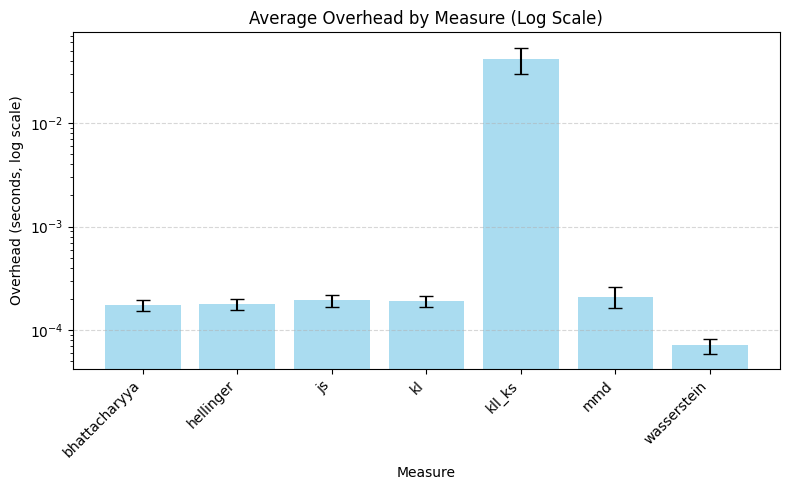

Saved results to: data-analysis/data-test/average_overhead_distribution.csv


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

def visualize_average_overhead_by_measure(all_results, output_csv_path):
    """
    Collapse across datasets, models, and drift_strength,
    and produce a bar chart of average overhead per measure (log scale).
    Save the results to a CSV file.
    """

    # 1) Convert 'all_results' into a pandas DataFrame
    rows = []
    for (dataset, model, measure, drift_strength), records in all_results.items():
        for rec in records:
            rows.append({
                "dataset": dataset,
                "model": model,
                "measure": measure,
                "drift_strength": drift_strength,
                "dist_val": rec["dist_val"],
                "time_taken": rec["time_taken"],
                "measure_overhead": rec["measure_overhead"],
                "seed": rec["seed"],
            })

    df = pd.DataFrame(rows)
    if df.empty:
        print("No results to visualize. DataFrame is empty.")
        return

    # 2) Group by just 'measure' (ignore dataset/model/drift_strength)
    #    and compute mean & std for measure_overhead
    grouped = (
        df.groupby("measure")["measure_overhead"]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={"mean": "overhead_mean", "std": "overhead_std"})
    )

    # 3) Create a bar plot (with error bars) for overhead per measure
    plt.figure(figsize=(8, 5))

    # X positions for each measure on the bar chart
    x_positions = range(len(grouped))

    # Bar chart
    plt.bar(
        x_positions,
        grouped["overhead_mean"],
        yerr=grouped["overhead_std"],
        capsize=5,
        alpha=0.7,
        color="skyblue"
    )

    # Apply log scale
    plt.yscale("log")  # <-- LOG SCALE applied

    # Label the x-axis with measure names
    plt.xticks(ticks=x_positions, labels=grouped["measure"], rotation=45, ha="right")

    plt.title("Average Overhead by Measure (Log Scale)")
    plt.xlabel("Measure")
    plt.ylabel("Overhead (seconds, log scale)")
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

    # Save the grouped DataFrame to a CSV file
    grouped.to_csv(output_csv_path, index=False)
    print(f"Saved results to: {output_csv_path}")

    return grouped

# Example usage:
output_csv_path = "data-analysis/data-test/average_overhead_distribution.csv"
grouped_df = visualize_average_overhead_by_measure(all_results, output_csv_path)